# 使用三维曲面图和散点图可视化学生考试成绩（PROC G3D）

## 执行摘要

本notebook使用 **PROC G3D** 来可视化两个教学干预因素如何在教育分析场景中共同
影响学生成绩。一个完整的析因网格驱动出一张平滑的预测考试成绩响应**曲面**，
覆盖每周学习时长（0 到 20）和既往 GPA（0 到 4），同时将 100 名学生组成的
合成群体按成绩等级分组渲染为**三维散点**面板。

拟合曲面在学习时长为零时的预测得分约为 26，向约 99 的上限攀升，并在学习
时长超过约 10 小时后趋于平缓——这正是模型所编码的边际收益递减脊线。学生
面板在个体层面证实了这一模式：20 名 *优秀* 学生（每一位得分均在 85 分及
以上）位于高 GPA、高学习时长的角落，而 33 名 *预警* 学生则集中在低努力、
低 GPA 区域。对该角落进行 WHERE 过滤后，隔离出 35 名学生，对他们而言，
学习时长的适度增加能带来最大的边际收益。

## 数据来源

所有数据均通过 `call streaminit()` 和 `rand()` 内联生成——无需外部文件或
网络访问。

**`score_grid`** —— 驱动响应曲面的完整析因网格（每个学习时长 x 既往 GPA
单元格一行，共 99 行）。

| 变量 | 类型 | 说明 |
|----------|------|-------------|
| `study_hours` | 数值 | 每周自主学习时长，0 到 20，步长 2（X 轴） |
| `prior_gpa` | 数值 | 既往学期 GPA，0–4 量表，0 到 4，步长 0.5（Y 轴） |
| `pred_score` | 数值 | 由饱和响应模型得出的期末考试成绩 0–100（Z 轴） |

**`students`** —— 用于散点图的合成个体学生群体（100 行）。

| 变量 | 类型 | 说明 |
|----------|------|-------------|
| `student_id` | 数值 | 学生序号标识 |
| `study_hours` | 数值 | 观测到的每周学习时长（X 轴） |
| `prior_gpa` | 数值 | 观测到的既往学期 GPA（Y 轴） |
| `exam_score` | 数值 | 观测到的期末考试成绩 0–100（Z 轴） |
| `cohort` | 字符 | 入学学期，`秋季` 或 `春季` |
| `band` | 字符 | 成绩等级：`优秀`（≥85）、`及格`（65–84）、`预警`（<65） |

网格特意设计为 99 个单元格，以便完整覆盖 0–20 的学习时长和 0–4 的 GPA
范围，同时保持在本环境 100 条观测的上限之内；11 x 9 的网格在不截断任一
坐标轴的前提下保持曲面平滑。

# 使用 PROC G3D 可视化学生考试成绩

教育研究者常常希望理解两个可塑因素如何共同驱动某个结果。这里我们提出的
问题是：*每周学习时长与学生既往 GPA 如何共同塑造期末考试表现？*

二维图表无法展示交互曲面。**PROC G3D** 使用 `y*x=z` 记法绘制真正的三维
图形，其中 X 和 Y 张成水平面，Z 垂直方向上升。我们使用它的两项能力：

- **PLOT** —— 在两个预测变量的完整网格上绘制连续响应**曲面**。
- **SCATTER** —— 将每名学生绘制为三维符号。我们为每个成绩等级各绘制一个
  面板，各自使用独立的标记颜色和形状，便于比较三个结果层级。

下面的一切都基于内联生成的合成数据运行，因此本notebook完全自包含。

## 步骤 1 —— 生成响应曲面网格

G3D 曲面图需要一个相当完整的网格：至少一半的 X-Y 单元格需要有非缺失的 Z
值。我们通过嵌套两个 `DO` 循环——分别遍历 `study_hours`（0 到 20，步长 2）
和 `prior_gpa`（0 到 4，步长 0.5）——来保证网格*完整*，形成一个 11 x 9、
共 99 个单元格的网格，完整覆盖两条坐标轴。

预测得分遵循一个合理的饱和模型：学习时长较高时收益递减，既往 GPA 大致呈
线性贡献，且二者存在交互作用（成绩较好的学生能更高效地把学习时间转化为
分数）。`rand('NORMAL')` 产生的小幅可重复扰动，使曲面看起来不会过于
"完美解析"。`call streaminit()` 固定了随机数种子，使网格可重复。

In [1]:
数据 score_grid;
   调用 streaminit(20260531);
   循环 study_hours = 0 到 20 按照 2;     /* 11 values: full 0-20 range */
      循环 prior_gpa = 0 到 4 按照 0.5;   /* 9 values  -> 99 grid cells */
         /* saturating return to study hours */
         effort = 40 * (1 - EXP(-study_hours / 6));
         /* prior achievement and an interaction term */
         BASE   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
         pred_score = 25 + effort + BASE + inter
                      + rand('NORMAL') * 1.5;
         如果 pred_score > 100 那么 pred_score = 100;
         如果 pred_score < 0   那么 pred_score = 0;
         输出;
      结束;
   结束;
   保留 study_hours prior_gpa pred_score;
运行;

过程 均值 数据=score_grid n MIN mean MAX maxdec=1;
   变量 study_hours prior_gpa pred_score;
   标签 study_hours = '每周学习时长'
         prior_gpa   = '既往学期GPA'
         pred_score  = '预测考试成绩';
运行;

                                                  The MEANS Procedure

 Variable     Label                     N     Minimum        Mean     Maximum
 ----------------------------------------------------------------------------
 study_hours  每周学习时长                   99         0.0        10.0        20.0
 prior_gpa    既往学期GPA                  99         0.0         2.0         4.0
 pred_score   预测考试成绩                   99        25.7        70.0        98.7
 ----------------------------------------------------------------------------




NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 步骤 2 —— 绘制基线响应曲面

有了完整的网格后，最简单的调用即可用过程默认设置绘制曲面。`PLOT y*x=z`
语法将 `prior_gpa` 映射到 Y 轴，`study_hours` 映射到 X 轴，预测得分映射
到垂直的 Z 轴。

我们用 `LABEL` 语句标注坐标轴，并用全局的 `TITLE`/`FOOTNOTE` 语句设置
标题和脚注，使图形清晰易读。

                                                       预测期末考试成绩曲面                                                       
                                                    每周学习时长与既往GPA的影响                                                     

PROC G3D Output
Data: score_grid

Variables: 每周学习时长, 既往学期GPA, 预测考试成绩

            每周学习时长          既往学期GPA              预测考试成绩
------------------  ---------------  ------------------
                 0                0       25.7031536911
                 0              0.5       28.9516502743
                 0                1       32.3400787822
                 0              1.5       36.8265757618
                 0                2       40.7806886968
                 0              2.5         42.61364606
                 0                3       49.4289293966
                 0              3.5       52.6020716414
                 0                4       55.6325677612
                 2                0       36.0797021538
               


NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to 预测期末考试成绩曲面.
NOTE: Option TITLE2 changed to 每周学习时长与既往GPA的影响.
NOTE: Option FOOTNOTE changed to 合成教育分析数据 .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


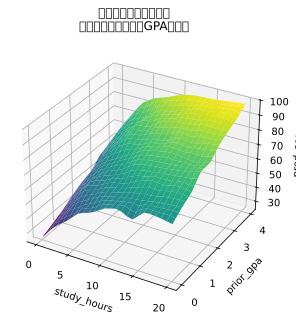

In [2]:
GOPTIONS reset=GLOBAL BORDER;

标题 '预测期末考试成绩曲面';
title2 '每周学习时长与既往GPA的影响';
footnote j=r '合成教育分析数据 ';

过程 g3d 数据=score_grid;
   PLOT prior_gpa*study_hours=pred_score;
   标签 study_hours = '每周学习时长'
         prior_gpa   = '既往学期GPA'
         pred_score  = '预测考试成绩';
运行;
QUIT;

## 步骤 3 —— 使用视角与坐标轴选项优化曲面

几个选项能让曲面清晰得多：

- **ROTATE=** 和 **TILT=** 设置观察视角（绕 Z 轴的旋转角度，以及朝向观察者
  的倾斜角度）。
- **XYTYPE=2** 绘制平行于 Y 轴的曲面线，强调得分如何随学习时长攀升。
- **SIDE** 添加侧墙，呈现坚实、雕塑般的外观。
- **GRID** 在主刻度处添加参考线。
- **ZMIN=/ZMAX=** 及 **ZTICKNUM=** 系列选项将得分轴固定为完整的 0–100
  范围，避免曲面在视觉上被夸大，而 **XTICKNUM=/YTICKNUM=** 控制地面
  刻度。
- **NAME=** 和 **DESCRIPTION=** 在输出目录中标注该图形。

                                                     预测考试成绩曲面（样式视图）                                                     
                                                      旋转、倾斜与坐标轴缩放                                                       

PROC G3D Output
Data: score_grid

Variables: 每周学习时长, 既往学期GPA, 预测考试成绩

            每周学习时长          既往学期GPA              预测考试成绩
------------------  ---------------  ------------------
                 0                0       25.7031536911
                 0              0.5       28.9516502743
                 0                1       32.3400787822
                 0              1.5       36.8265757618
                 0                2       40.7806886968
                 0              2.5         42.61364606
                 0                3       49.4289293966
                 0              3.5       52.6020716414
                 0                4       55.6325677612
                 2                0       36.0797021538
               


NOTE: Option TITLE changed to 预测考试成绩曲面（样式视图）.
NOTE: Option TITLE2 changed to 旋转、倾斜与坐标轴缩放.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


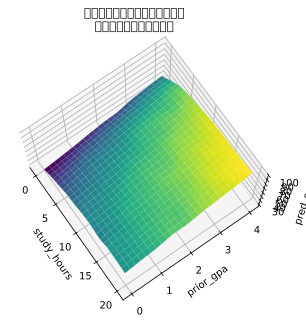

In [3]:
标题 '预测考试成绩曲面（样式视图）';
title2 '旋转、倾斜与坐标轴缩放';

过程 g3d 数据=score_grid;
   PLOT prior_gpa*study_hours=pred_score /
        ROTATE=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="样式化的考试成绩响应曲面";
   标签 study_hours = '每周学习时长'
         prior_gpa   = '既往学期GPA'
         pred_score  = '预测考试成绩';
运行;
QUIT;

## 步骤 4 —— 从多个视角比较曲面

由于三维曲面可能会将结构隐藏在自身的峰值之后，从多个旋转角度渲染同一
曲面会很有帮助。这里我们执行三个 PROC G3D 步骤，它们共用固定的倾斜角，
但将 **ROTATE=** 角度依次设为 30、90 和 150 度，以便从正面、侧面和
背面检视这道脊线。

                                                          响应曲面                                                          
                                                   ROTATE = 30（固定倾斜角）                                                   

PROC G3D Output
Data: score_grid

Variables: 每周学习时长, 既往学期GPA, 预测考试成绩

            每周学习时长          既往学期GPA              预测考试成绩
------------------  ---------------  ------------------
                 0                0       25.7031536911
                 0              0.5       28.9516502743
                 0                1       32.3400787822
                 0              1.5       36.8265757618
                 0                2       40.7806886968
                 0              2.5         42.61364606
                 0                3       49.4289293966
                 0              3.5       52.6020716414
                 0                4       55.6325677612
                 2                0       36.0797021538
               


NOTE: Option TITLE changed to 响应曲面.
NOTE: Option TITLE2 changed to ROTATE = 30（固定倾斜角）.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to 响应曲面.
NOTE: Option TITLE2 changed to ROTATE = 90（固定倾斜角）.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to 响应曲面.
NOTE: Option TITLE2 changed to ROTATE = 150（固定倾斜角）.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


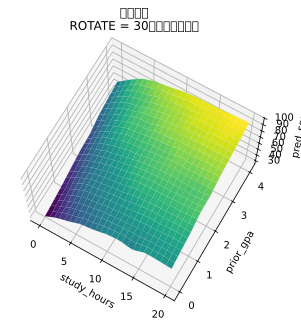

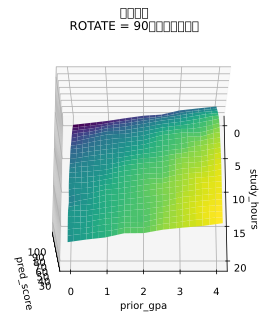

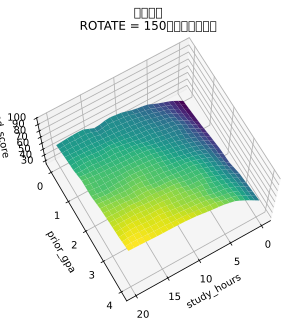

In [4]:
%macro angle(deg);
   标题 '响应曲面';
   title2 "ROTATE = &deg（固定倾斜角）";
   过程 g3d 数据=score_grid;
      PLOT prior_gpa*study_hours=pred_score /
           ROTATE=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      标签 study_hours = '每周学习时长'
            prior_gpa   = '既往学期GPA'
            pred_score  = '预测考试成绩';
   运行;
   QUIT;
%mend;

%angle(30);
%angle(90);
%angle(150);

## 步骤 5 —— 生成合成学生群体

曲面是一个模型；真实学生会围绕它散布。我们现在模拟 100 名个体学生，
分别来自两个入学学期（`秋季`、`春季`）。每名学生都有观测到的学习时长、
既往 GPA，以及由同一响应逻辑加上更大个体差异生成的带噪声的实际考试
成绩。

随后我们根据考试成绩推导出成绩**等级**：`优秀`（85 分及以上）、
`及格`（65 到 84 分）以及`预警`（低于 65 分）。下面的 PROC FREQ 交叉表
报告了各等级在两个学期中的分布情况。`rand('UNIFORM')` 和 `rand('NORMAL')`
提供随机性；种子确保结果可重复。

                                                          响应曲面                                                          
                                                  ROTATE = 150（固定倾斜角）                                                   

                                                   The FREQ Procedure

                             Cumulative
成绩等级            Frequency    Frequency
------------------------------------------
优秀                     20           20
及格                     47           67
预警                     33          100

Table of 入学学期 by 成绩等级

入学学期         |        优秀 |        及格 |        预警 |      Total
-------------+-----------+-----------+-----------+-----------
春季           |        14 |        27 |        18 |         59
-------------+-----------+-----------+-----------+-----------
秋季           |         6 |        20 |        15 |         41
-------------+-----------+-----------+-----------+-----------
Total        |        20 |        47 |        33 | 


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


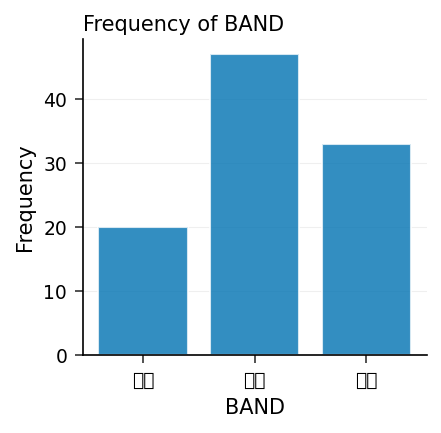

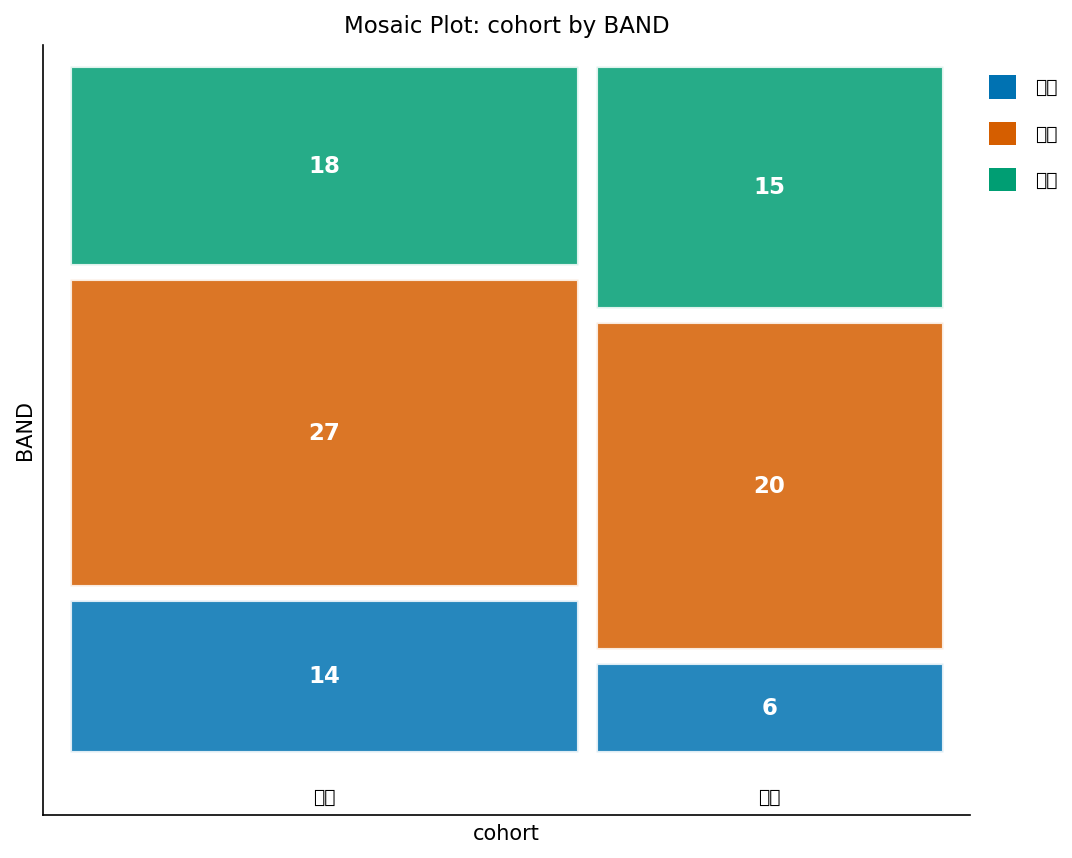

In [5]:
数据 students;
   调用 streaminit(99001);
   长度 cohort $8 BAND $10;
   循环 student_id = 1 到 100;
      如果 rand('UNIFORM') < 0.5 那么 cohort = '秋季';
      否则 cohort = '春季';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - EXP(-study_hours / 6));
      BASE   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
      exam_score = 25 + effort + BASE + inter
                   + rand('NORMAL') * 7;
      如果 exam_score > 100 那么 exam_score = 100;
      如果 exam_score < 0   那么 exam_score = 0;

      如果 exam_score >= 85 那么 BAND = '优秀';
      否则 如果 exam_score >= 65 那么 BAND = '及格';
      否则 BAND = '预警';

      输出;
   结束;
   保留 student_id cohort study_hours prior_gpa exam_score BAND;
运行;

过程 频率 数据=students;
   TABLES BAND cohort*BAND / nocol nopercent;
   标签 BAND = '成绩等级' cohort = '入学学期';
运行;

## 步骤 6 —— 按成绩等级绘制学生的三维散点面板

**SCATTER** 语句将每名学生绘制为一个三维符号。为了让三个成绩层级易于
辨读，我们为每个等级各绘制一个面板，各自用 **WHERE** 过滤，并分别赋予
自己的字面量 **COLOR=** 和 **SHAPE=**：绿色菱形（`SHAPE=diamond`）代表
*优秀*，蓝色标记（`SHAPE=club`）代表*及格*，红色标记（`SHAPE=spade`）
代表*预警*。**SIZE=** 放大标记，**GRID** 添加地面参考线，**NONEEDLE**
移除竖直的垂线，**ZMIN=/ZMAX=** 使每个面板都保持相同的 0–100 分数轴，
以便三个视图可以直接比较。

每个等级都拥有各自的 PROC G3D 步骤，以便其 WHERE 过滤条件干净地生效，
标记样式也不会产生歧义。

                                                          优秀学生                                                          
                                                       考试成绩85分及以上                                                       

PROC G3D Output
Data: students

Variables: student_id, cohort, 每周学习时长, 既往学期GPA, 期末考试成绩, BAND

student_id      cohort              每周学习时长          既往学期GPA              期末考试成绩        BAND
----------  ----------  ------------------  ---------------  ------------------  ----------
         2          春季       19.2134883194     2.6467742616       90.3663886999          优秀
         5          春季       15.5520919174     2.7102003827       94.9419468332          优秀
        10          春季       14.2302640951     3.8791496428                 100          优秀
        17          春季       13.7403346635     2.7462821708       89.6648779222          优秀
        25          秋季       18.7592154739      3.639636185                 100          优秀
        32         


NOTE: Option FOOTNOTE changed to 来自100名合成学生的队列 .
NOTE: Option TITLE changed to 优秀学生.
NOTE: Option TITLE2 changed to 考试成绩85分及以上.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to 及格学生.
NOTE: Option TITLE2 changed to 考试成绩65至84分.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to 预警学生.
NOTE: Option TITLE2 changed to 考试成绩低于65分.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


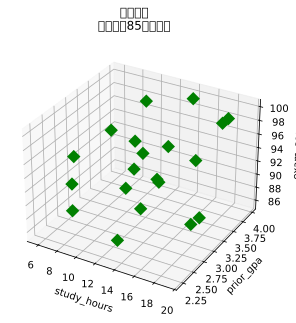

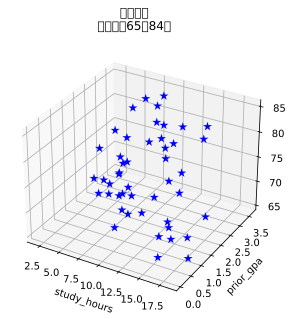

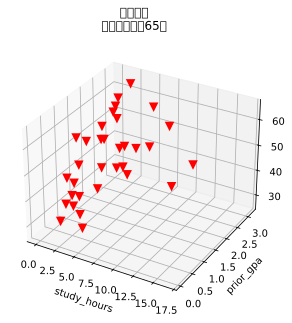

In [6]:
footnote j=r '来自100名合成学生的队列 ';

/* Honors (exam_score >= 85): green diamonds */
标题 '优秀学生';
title2 '考试成绩85分及以上';
过程 g3d 数据=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="优秀学生";
   条件 BAND = '优秀';
   标签 study_hours = '每周学习时长'
         prior_gpa   = '既往学期GPA'
         exam_score  = '期末考试成绩';
运行;
QUIT;

/* Pass (65 <= exam_score < 85): blue clubs */
标题 '及格学生';
title2 '考试成绩65至84分';
过程 g3d 数据=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="及格学生";
   条件 BAND = '及格';
   标签 study_hours = '每周学习时长'
         prior_gpa   = '既往学期GPA'
         exam_score  = '期末考试成绩';
运行;
QUIT;

/* AtRisk (exam_score < 65): red spades */
标题 '预警学生';
title2 '考试成绩低于65分';
过程 g3d 数据=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="预警学生";
   条件 BAND = '预警';
   标签 study_hours = '每周学习时长'
         prior_gpa   = '既往学期GPA'
         exam_score  = '期末考试成绩';
运行;
QUIT;

## 步骤 7 —— 按入学学期分别绘制散点图（BY 分组）

项目负责人常常需要按学期拆分查看同一视图。**BY** 语句为每个学期生成一
张散点图。G3D 要求 BY 分组数据已排序，因此我们先用 PROC SORT 排序。随后
每个学期都会在共享的 0–100 分数轴上得到自己的带标签三维散点图，便于并排
比较秋季和春季的分布。

                                                      按入学学期划分的考试结果                                                      
                                                   每个学期一张三维散点图（秋季、春季）                                                   

PROC G3D Output
Data: students_sorted

Variables: student_id, cohort, 每周学习时长, 既往学期GPA, 期末考试成绩, BAND

student_id      cohort              每周学习时长          既往学期GPA              期末考试成绩        BAND
----------  ----------  ------------------  ---------------  ------------------  ----------
        53          春季       10.7875369915     3.0789706431       76.6136428341          及格
       100          春季       10.7782420031     3.5469548845                 100          优秀
         4          春季        8.3587240648     1.1475897699       65.4995231815          及格
         5          春季       15.5520919174     2.7102003827       94.9419468332          优秀
         2          春季       19.2134883194     2.6467742616       90.3663886999          优秀
         7  


NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to 按入学学期划分的考试结果.
NOTE: Option TITLE2 changed to 每个学期一张三维散点图（秋季、春季）.
NOTE: Option FOOTNOTE changed to 每个学期一个面板 .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


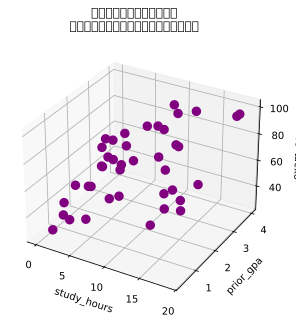

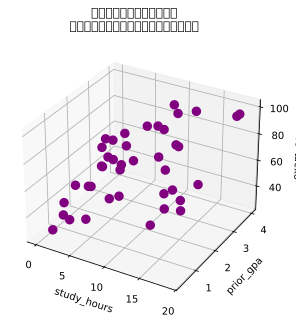

In [7]:
过程 排序 数据=students out=students_sorted;
   按照 cohort;
运行;

标题 '按入学学期划分的考试结果';
title2 '每个学期一张三维散点图（秋季、春季）';
footnote j=r '每个学期一个面板 ';

过程 g3d 数据=students_sorted;
   按照 cohort;
   SCATTER prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   标签 study_hours = '每周学习时长'
         prior_gpa   = '既往学期GPA'
         exam_score  = '期末考试成绩';
运行;
QUIT;

## 步骤 8 —— 用 WHERE 聚焦预警区域

对于干预规划而言，最具可操作性的视图是曲面的左下角：学习时长较少
（8 小时或以下）且既往 GPA 较低（2.5 或以下）的学生。**WHERE** 语句
在绘图前将散点子集限定到该区域。清单显示这一角落包含 100 名学生中的
35 名——其中 22 名已经是*预警*等级——因此指导老师能准确看到哪些困难
学生离预期水平最远。

                                                    干预重点：低努力、低GPA学生                                                     
                                          study_hours <= 8 且 prior_gpa <= 2.5                                           

PROC G3D Output
Data: students

Variables: student_id, cohort, 每周学习时长, 既往学期GPA, 期末考试成绩, BAND

student_id      cohort              每周学习时长          既往学期GPA              期末考试成绩        BAND
----------  ----------  ------------------  ---------------  ------------------  ----------
         1          秋季        4.9780700766      1.072086769        59.409228777          预警
         7          春季        7.9015823058     1.6623636789       66.9055021729          及格
         9          春季        2.5008494545     0.3621033759       48.1183184446          预警
        11          春季        7.1907276895     2.1821388818        79.351887155          及格
        13          秋季        5.8493366471     1.8449001873       70.6084324429          及格
        14         


NOTE: Option TITLE changed to 干预重点：低努力、低GPA学生.
NOTE: Option TITLE2 changed to study_hours <= 8 且 prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to 垂线将每个标记点连接到自习时长×GPA平面 .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


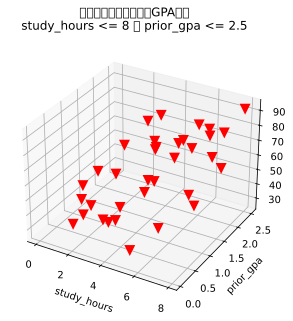

In [8]:
标题 '干预重点：低努力、低GPA学生';
title2 'study_hours <= 8 且 prior_gpa <= 2.5';
footnote j=r '垂线将每个标记点连接到自习时长×GPA平面 ';

过程 g3d 数据=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   条件 study_hours <= 8 并且 prior_gpa <= 2.5;
   标签 study_hours = '每周学习时长'
         prior_gpa   = '既往学期GPA'
         exam_score  = '期末考试成绩';
运行;
QUIT;

## 结果解读

**响应曲面**（步骤 2–4）展示出一道清晰的饱和脊线。在 99 个单元格组成
的网格中，预测得分从约 26（学习时长为零、GPA 为零）攀升到约 99（高
时长、高 GPA 的角落），网格整体均值接近 70。沿学习时长轴观察，得分从
0 开始陡峭上升，直到约 10 小时左右，随后由于额外时长带来的收益递减而
趋于平缓；沿 GPA 轴观察，既往成绩会将整个曲面向上平移。交互项使得
学习时长的回报对成绩较好的学生略微更陡峭，这就是曲面朝远端角落倾斜、
而非呈现为一个平面的原因。

**学生面板**（步骤 6–7）证实该模型在个体层面同样成立。100 名学生的
群体分为 20 名*优秀*、47 名*及格*和 33 名*预警*学生。在等级面板中，
20 颗绿色*优秀*菱形——每一个得分都在 85 分及以上——位于既往 GPA 2.2
以上、每周学习时长至少约 6 小时的位置，聚集在地面上的右上角。33 个
红色*预警*标记则集中在低努力、低 GPA 区域，恰好是曲面的谷底。按学期
拆分显示，秋季（41 名学生）和春季（59 名学生）的分布大体相似，说明
结果由这两个因素驱动，而非入学时间。

**WHERE 过滤视图**（步骤 8）隔离出干预对象群体：35 名学习时长 8 小时
或以下、GPA 2.5 或以下的学生。其中 22 名已经是*预警*等级，只有 1 名
达到*优秀*。在这一角落内，实际得分仍随学习时长明显上升——这是一个
具体、直观的论据，说明在最需要的地方，结构化学习时间的适度增加能带来
最大的边际收益。

综上所述，PROC G3D 将一个双因素交互模型转化为一幅直观、可供决策的
图景，供教育项目使用：得分上限在哪里、谁尚未达到这一上限，以及在哪里
投入辅导精力最能获得回报。

> **实现说明。** SAS/GRAPH 还允许单条 SCATTER 语句根据逐观测变量
> （`COLOR=<字符变量>`、`SHAPE=<字符变量>`）为每个标记着色和定形。该
> 逐观测形式在本引擎中尚未渲染，因此本notebook改为每个等级绘制一个
> 字面量着色的面板——一种等效且完全可用的呈现方式。该差距由已归档的
> 回归测试 `tests/401000_nb_g3d_scatter_color_variable_unrendered` 跟踪。